PART1: Geostrophic transport

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from correlation_trends.data_io import load_ts_gridded, load_amoc
from correlation_trends.geostrophy import interior_geostrophic_transport

ts = load_ts_gridded() 
 
time_amoc, dt_amoc, series = load_amoc()
umo = series["TRANS_UMO"]

#Computing interior geostrophic transport
trans = interior_geostrophic_transport(ts, z_max=1100.0)
print(trans.shape, trans.attrs)
print("mean transport:", trans.values.mean(), "Sv")




Loading 1 RAPID 26°N dataset(s):
  0. ts_gridded.nc: RAPID gridded temperature and salinity

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series

(14599,) {'units': 'Sv', 'long_name': 'Upper mid-ocean geostrophic transport', 'reference_pressure': 4820.0, 'integration_depth_m': 1100.0}
mean transport: -13.455613768215015 Sv


Comparision to Trans_Umo

In [13]:
t_ours = trans["TIME"].values.astype("datetime64[ns]").astype("int64")
t_umo = time_amoc.astype("datetime64[ns]").astype("int64")
umo_on_ours = np.interp(t_ours, t_umo, umo)

ours = trans.values
good = np.isfinite(ours) & np.isfinite(umo_on_ours)
ours_g, umo_g = ours[good], umo_on_ours[good]

r = np.corrcoef(ours_g, umo_g)[0, 1]
slope, intercept = np.polyfit(umo_g, ours_g, 1)
mean_offset = np.mean(ours_g) - np.mean(umo_g)

print("N matched points  :", good.sum())
print("Regression: Interior = %.3f * UMO + %.3f" % (slope, intercept))

N matched points  : 14599
Regression: Interior = 1.228 * UMO + 9.100


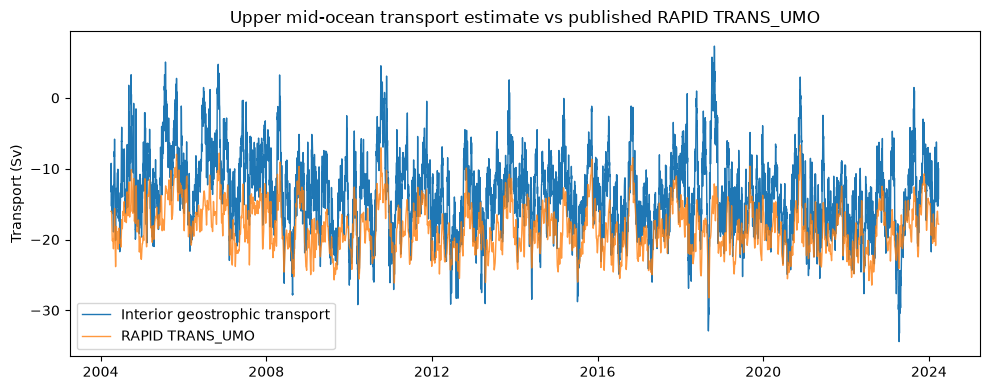

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trans["TIME"].values, ours, label="Interior geostrophic transport", lw=1)
ax.plot(trans["TIME"].values, umo_on_ours, label="RAPID TRANS_UMO", lw=1, alpha=0.8)
ax.set_ylabel("Transport (Sv)")
ax.set_title("Upper mid-ocean transport estimate vs published RAPID TRANS_UMO")
ax.legend()
plt.tight_layout()
plt.savefig("figs/part1_overlay.png", dpi=150)
plt.show()

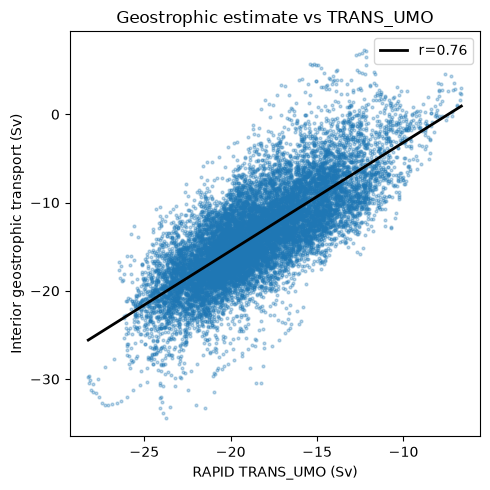

In [22]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(umo_g, ours_g, s=4, alpha=0.3)
xline = np.linspace(umo_g.min(), umo_g.max(), 2)
ax.plot(xline, slope * xline + intercept, color="k", lw=2,
         label=f"r={r:.2f}")
ax.set_xlabel("RAPID TRANS_UMO (Sv)")
ax.set_ylabel("Interior geostrophic transport (Sv)")
ax.set_title("Geostrophic estimate vs TRANS_UMO")
ax.legend()
plt.tight_layout()
plt.savefig("figs/part1_scatter.png", dpi=150)
plt.show()

PART2 Evaluating time series

2A — Single series: seasonal cycle and trend